# Learning to Play Snake with Reinforcement Learning

**Problem Statement:** Reinforcement Learning (RL) trains an agent to make decisions by interacting with an environment to maximize rewards. In this project, we apply RL to Snake using the OpenAI Gymnasium environment.

The following code is provided to help you get started. For neural network approaches, we recommend using GPUs train the models.

## 1. Install and Import Dependencies

In [ ]:
import sys
print(sys.executable)
print(sys.version)

#comment out when finish download
# !{sys.executable} -m pip install -U matplotlib seaborn tqdm
# !{sys.executable} -m pip install -U gymnasium matplotlib seaborn tqdm torch
# !{sys.executable} -m pip install -U pygame
# !{sys.executable} -m pip install -U pandas

/usr/local/bin/python3.13
3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [81]:
# Install gymnasium if needed
# ! pip install gymnasium matplotlib numpy seaborn

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
# from collections import defaultdict
from tqdm import tqdm
import pandas as pd


print(f"Gymnasium version: {gym.__version__}")

Gymnasium version: 1.2.3


## 2. Set Up and Explore the Snake Environment

The Snake-v1 environment simulates the classic grid-based Snake game with the following:
- **State**: A feature vector describing the snake’s immediate situation (compact, learnable representation).
  - `danger_straight` (0/1): (0/1): Collision if the snake continues forward

  - `danger_left` (0/1): Collision if the snake turns left

  - `danger_right` (0/1): Collision if the snake turns right

  - `food_left` (0/1): Food is to the left of the head

  - `food_right` (0/1): Food is to the right of the head

  - `food_up` (0/1): Food is above the head

  - `food_down` (0/1): Food is below the head

  - `moving_left` (0/1): Snake is currently moving left

  - `moving_right` (0/1): Snake is currently moving right

  - `moving_up` (0/1): Snake is currently moving up
  
  - `moving_down` (0/1): Snake is currently moving down
  
- **Actions**: 0 = Straight 1 = Turn Left 2 = Turn Right 
- **Rewards**: +10 when snake eats food, -10 when the snake dies, -0.1 each step taken 
- **done condition**: snake collides with a wall, with its own body, max limit reached

In [ ]:

class SnakeEnv(gym.Env):
    """
    Minimal Snake environment (work-in-progress).
    Actions: 0=Straight, 1=Left, 2=Right
    Observation: 11-dim feature vector
    """

    
    REWARD_EAT = 10.0
    PENALTY_DEATH = -10.0
    STEP_PENALTY = -0.1

    def __init__(self, grid_size=10, max_steps=500):
        super().__init__()
        self.grid_size = grid_size
        self.max_steps = max_steps

        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(11,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0

        mid = self.grid_size // 2
        self.direction = (1, 0)  # right
        self.snake = [(mid, mid), (mid - 1, mid), (mid - 2, mid)]
        self._spawn_food()

        obs = self._get_obs()
        info = {}
        return obs, info

    def step(self, action):
        self.steps += 1

       
        self.direction = self._turn(self.direction, action)

    
        head_x, head_y = self.snake[0]
        dx, dy = self.direction
        new_head = (head_x + dx, head_y + dy)

        reward = self.STEP_PENALTY
        terminated = False
        truncated = False

        # Collision with wall
        if not (0 <= new_head[0] < self.grid_size and 0 <= new_head[1] < self.grid_size):
            reward = self.PENALTY_DEATH
            terminated = True

        # Collision with self
        elif new_head in self.snake:
            reward = self.PENALTY_DEATH
            terminated = True

        else:
            # Advance snake
            self.snake.insert(0, new_head)

            # Eat food
            if new_head == self.food:
                reward = self.REWARD_EAT
                self._spawn_food()
            else:
                self.snake.pop()  

        if self.steps >= self.max_steps:
            truncated = True

        obs = self._get_obs()
        info = {"length": len(self.snake)}
        return obs, reward, terminated, truncated, info

    # ---------- Helpers ----------

    def _spawn_food(self):
        while True:
            fx = self.np_random.integers(0, self.grid_size)
            fy = self.np_random.integers(0, self.grid_size)
            if (fx, fy) not in self.snake:
                self.food = (fx, fy)
                return

    def _turn(self, direction, action):
        dx, dy = direction
        if action == 0:      # straight
            return (dx, dy)
        if action == 1:      # left
            return (-dy, dx)
        else:                # right
            return (dy, -dx)

    def _danger(self, direction):
        head_x, head_y = self.snake[0]
        dx, dy = direction
        nxt = (head_x + dx, head_y + dy)
        if not (0 <= nxt[0] < self.grid_size and 0 <= nxt[1] < self.grid_size):
            return 1.0
        if nxt in self.snake:
            return 1.0
        return 0.0

    def _get_obs(self):
        head_x, head_y = self.snake[0]
        fx, fy = self.food
        dx, dy = self.direction

        straight = (dx, dy)
        left = (-dy, dx)
        right = (dy, -dx)

        danger_straight = self._danger(straight)
        danger_left = self._danger(left)
        danger_right = self._danger(right)

        food_left = 1.0 if fx < head_x else 0.0
        food_right = 1.0 if fx > head_x else 0.0
        food_up = 1.0 if fy < head_y else 0.0
        food_down = 1.0 if fy > head_y else 0.0

        moving_left = 1.0 if (dx, dy) == (-1, 0) else 0.0
        moving_right = 1.0 if (dx, dy) == (1, 0) else 0.0
        moving_up = 1.0 if (dx, dy) == (0, -1) else 0.0
        moving_down = 1.0 if (dx, dy) == (0, 1) else 0.0

        return np.array([
            danger_straight, danger_left, danger_right,
            food_left, food_right, food_up, food_down,
            moving_left, moving_right, moving_up, moving_down
        ], dtype=np.float32)

In [32]:
# Create the environment
env = SnakeEnv()


print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print("Actions: 0=Straight, 1=Turn Left, 2=Turn Right")

Observation space: Box(0.0, 1.0, (11,), float32)
Action space: Discrete(3)
Actions: 0=Straight, 1=Turn Left, 2=Turn Right


In [33]:
#sample random episodes to understand the enviorment 
print("=== Sample Episodes ===")

for episode in range(5):

    state, info = env.reset()
    print(f"\nEpisode {episode + 1}")
    print(f"Initial state: {state}")

    done = False
    step = 0

    while not done:

        # Random action for demonstration
        action = env.action_space.sample()

        if action == 0:
            action_name = "Straight"
        elif action == 1:
            action_name = "Turn Left"
        else:
            action_name = "Turn Right"

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        step += 1

        print(
            f"Step {step}: "
            f"Action={action_name}, "
            f"Reward={reward}, "
            f"Length={info['length']}"
        )

        state = next_state

    print(f"Episode finished after {step} steps. Final length: {info['length']}")

=== Sample Episodes ===

Episode 1
Initial state: [0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0.]
Step 1: Action=Turn Right, Reward=-0.1, Length=3
Step 2: Action=Turn Right, Reward=-0.1, Length=3
Step 3: Action=Turn Right, Reward=-0.1, Length=3
Step 4: Action=Turn Left, Reward=-0.1, Length=3
Step 5: Action=Straight, Reward=-0.1, Length=3
Step 6: Action=Straight, Reward=-0.1, Length=3
Step 7: Action=Turn Right, Reward=-0.1, Length=3
Step 8: Action=Turn Right, Reward=-0.1, Length=3
Step 9: Action=Turn Left, Reward=-0.1, Length=3
Step 10: Action=Turn Left, Reward=-0.1, Length=3
Step 11: Action=Turn Left, Reward=-0.1, Length=3
Step 12: Action=Straight, Reward=-0.1, Length=3
Step 13: Action=Turn Right, Reward=-0.1, Length=3
Step 14: Action=Turn Right, Reward=-0.1, Length=3
Step 15: Action=Turn Left, Reward=-10.0, Length=3
Episode finished after 15 steps. Final length: 3

Episode 2
Initial state: [0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0.]
Step 1: Action=Turn Left, Reward=-0.1, Length=3
Step 2: Action=Straight, R

## 3. Random Policy Baseline(Snake)

We've provided two simple baselines:

1. Random policy agent: This agent selects a action uniformly at random at every step.
    - actions: straight, turn left, turn right 

2. greedy: it always tries to reduce distance to the food NO MATTER WHAT, even if that risks dying

Our Goal: to outperform the baselines on average on scores and survival time

In [ ]:

def evaluate_policy(env, policy_fn, n_episodes=2000):
    """
    Evaluate a Snake policy over many episodes.

    Args:
        env: SnakeEnv
        policy_fn: function(state) -> action
        n_episodes: number of episodes to simulate

    Returns:
        Dictionary of evaluation metrics.
    """
    scores = []
    steps_list = []
    total_rewards = []
    deaths = 0

    for _ in range(n_episodes):
        state, info = env.reset()
        done = False
        steps = 0
        ep_reward = 0.0

        start_len = info.get("length", 3)

        while not done:
            action = policy_fn(state)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            ep_reward += reward
            steps += 1

            if terminated:
                deaths += 1

        final_len = info.get("length", start_len)
        score = final_len - start_len  # foods eaten ≈ length increase

        scores.append(score)
        steps_list.append(steps)
        total_rewards.append(ep_reward)

    return {
        "avg_score": float(np.mean(scores)),
        "median_score": float(np.median(scores)),
        "avg_steps": float(np.mean(steps_list)),
        "death_rate": float(deaths / n_episodes),
        "avg_total_reward": float(np.mean(total_rewards))
    }

## 3a. Random Policy + Greedy Policy

In [75]:
def greedy_to_food_action(state):
    food_left  = state[3] == 1.0
    food_right = state[4] == 1.0
    food_up    = state[5] == 1.0
    food_down  = state[6] == 1.0

    moving_left  = state[7] == 1.0
    moving_right = state[8] == 1.0
    moving_up    = state[9] == 1.0
    moving_down  = state[10] == 1.0


    if food_left:
        target = "LEFT"
    elif food_right:
        target = "RIGHT"
    elif food_up:
        target = "UP"
    elif food_down:
        target = "DOWN"
    else:
        return 0  # straight

    if moving_right:
        if target == "RIGHT": return 0
        if target == "UP":    return 1
        if target == "DOWN":  return 2
        if target == "LEFT":  return 1
    elif moving_left:
        if target == "LEFT":  return 0
        if target == "DOWN":  return 1
        if target == "UP":    return 2
        if target == "RIGHT": return 1
    elif moving_up:
        if target == "UP":    return 0
        if target == "LEFT":  return 1
        if target == "RIGHT": return 2
        if target == "DOWN":  return 1
    elif moving_down:
        if target == "DOWN":  return 0
        if target == "RIGHT": return 1
        if target == "LEFT":  return 2
        if target == "UP":    return 1

    return 0

In [76]:
random_policy = lambda state: env.action_space.sample()

metrics = evaluate_policy(env, random_policy, n_episodes=2000)
print("Random Policy:")
print(f"  Avg score: {metrics['avg_score']:.3f}")
print(f"  Median score: {metrics['median_score']:.3f}")
print(f"  Avg steps: {metrics['avg_steps']:.1f}")
print(f"  Death rate: {metrics['death_rate']:.3%}")

metrics = evaluate_policy(env, greedy_to_food_action, n_episodes=2000)

print("Greedy-to-Food Policy (ignores danger):")
print(f"  Avg score: {metrics['avg_score']:.3f}")
print(f"  Median score: {metrics['median_score']:.3f}")
print(f"  Avg steps: {metrics['avg_steps']:.1f}")
print(f"  Death rate: {metrics['death_rate']:.3%}")
print(f"  Avg total reward: {metrics['avg_total_reward']:.3f}")


Random Policy:
  Avg score: 0.179
  Median score: 0.000
  Avg steps: 18.9
  Death rate: 100.000%
Greedy-to-Food Policy (ignores danger):
  Avg score: 0.044
  Median score: 0.000
  Avg steps: 10.5
  Death rate: 100.000%
  Avg total reward: -10.505


   Policy  Avg Score  Avg Steps
0  Random      0.179    19.1155
1  Greedy      0.043    10.6495


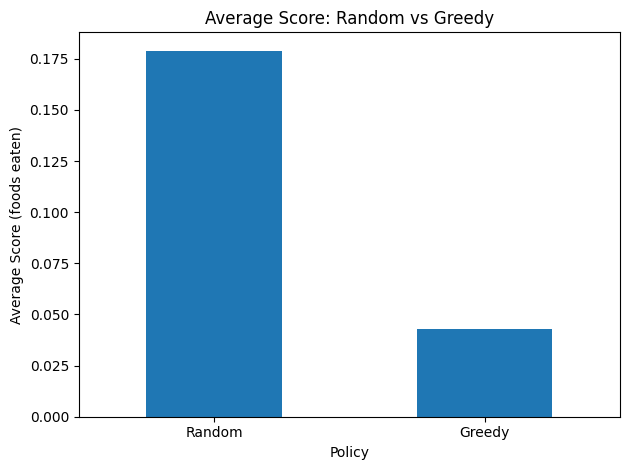

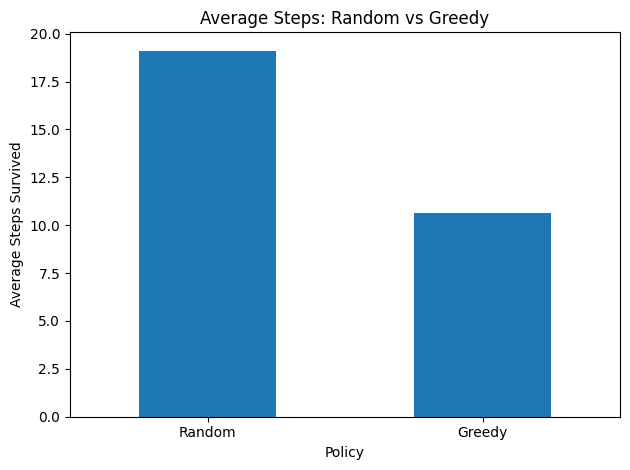

In [80]:


# Evaluate both policies
random_metrics = evaluate_policy(env, lambda s: env.action_space.sample(), n_episodes=2000)
greedy_metrics = evaluate_policy(env, greedy_to_food_action, n_episodes=2000)

# Build a DataFrame for comparison
df = pd.DataFrame([
    {"Policy": "Random", "Avg Score": random_metrics["avg_score"], "Avg Steps": random_metrics["avg_steps"]},
    {"Policy": "Greedy", "Avg Score": greedy_metrics["avg_score"], "Avg Steps": greedy_metrics["avg_steps"]},
])

print(df)

# --- Bar graph: Average Score ---
ax = df.plot(x="Policy", y="Avg Score", kind="bar", legend=False)
ax.set_title("Average Score: Random vs Greedy")
ax.set_ylabel("Average Score (foods eaten)")
ax.set_xlabel("Policy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Bar graph: Average Steps ---
ax = df.plot(x="Policy", y="Avg Steps", kind="bar", legend=False)
ax.set_title("Average Steps: Random vs Greedy")
ax.set_ylabel("Average Steps Survived")
ax.set_xlabel("Policy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()